<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Image_Classification_RandomForest_Assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification with Random Forest and SVM

This notebook uses the uploaded `images.zip` dataset to classify images into five categories: dalmatian, dollar_bill, pizza, soccer_ball, and sunflower. The workflow covers preprocessing, Random Forest with GridSearchCV, model evaluation, feature importance, prediction on a new image, and a bonus SVM comparison.

In [17]:
import os, zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## 1. Extract and inspect dataset

In [18]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images (1).zip


In [19]:
zip_path = '/content/images.zip'
extract_dir = '/content/images_extracted'
shutil.rmtree(extract_dir, ignore_errors=True)
with zipfile.ZipFile(zip_path) as zf:
    zf.extractall(extract_dir)

base_dir = os.path.join(extract_dir, 'images')
files = []
for cls in sorted(os.listdir(base_dir)):
    cls_dir = os.path.join(base_dir, cls)
    if os.path.isdir(cls_dir):
        for file_name in sorted(os.listdir(cls_dir)):
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                files.append((os.path.join(cls_dir, file_name), cls))

class_counts = pd.Series([c for _, c in files]).value_counts().sort_index()
print('Number of images:', len(files))
print(class_counts)


Number of images: 309
dalmatian      67
dollar_bill    51
pizza          52
soccer_ball    54
sunflower      85
Name: count, dtype: int64


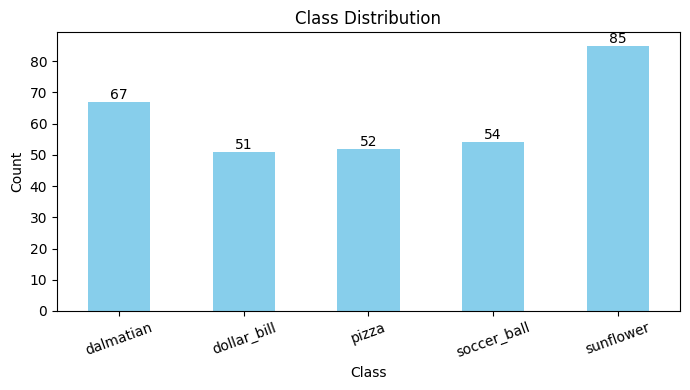

In [20]:
plt.figure(figsize=(7,4))
ax = class_counts.plot(kind='bar', color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 2. Preprocess images
Images are resized to 20x20 pixels, converted to grayscale, normalized to the [0,1] range, and flattened into feature vectors for classical ML models.

In [21]:
def load_images(file_list, size=(20,20), grayscale=True):
    X, y, paths = [], [], []
    for path, label in file_list:
        img = Image.open(path).convert('L' if grayscale else 'RGB').resize(size)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        X.append(arr.flatten())
        y.append(label)
        paths.append(path)
    return np.array(X), np.array(y), np.array(paths)

X, y, paths = load_images(files, size=(20,20), grayscale=True)
print('Feature matrix shape:', X.shape)


Feature matrix shape: (309, 400)


In [22]:
X_train, X_test, y_train, y_test, path_train, path_test = train_test_split(
    X, y, paths, test_size=0.2, random_state=42, stratify=y
)
print('Training set:', X_train.shape, y_train.shape)
print('Testing set:', X_test.shape, y_test.shape)


Training set: (247, 400) (247,)
Testing set: (62, 400) (62,)


## 3. Random Forest with GridSearchCV

In [23]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42, n_jobs=1)
rf_grid = GridSearchCV(rf, param_grid, cv=cv, scoring='accuracy', n_jobs=1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print('Best parameters:', rf_grid.best_params_)
best_rf


Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


RandomForestClassifier(min_samples_split=5, n_jobs=1, random_state=42)

In [24]:
rf_pred = best_rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average='weighted', zero_division=0)
print('Accuracy:', round(rf_accuracy, 3))
print('Precision:', round(rf_precision, 3))
print('Recall:', round(rf_recall, 3))
print('F1-score:', round(rf_f1, 3))


Accuracy: 0.677
Precision: 0.694
Recall: 0.677
F1-score: 0.673


              precision    recall  f1-score   support

   dalmatian       0.77      0.71      0.74        14
 dollar_bill       0.83      0.50      0.62        10
       pizza       0.62      0.50      0.56        10
 soccer_ball       0.67      0.73      0.70        11
   sunflower       0.61      0.82      0.70        17

    accuracy                           0.68        62
   macro avg       0.70      0.65      0.66        62
weighted avg       0.69      0.68      0.67        62



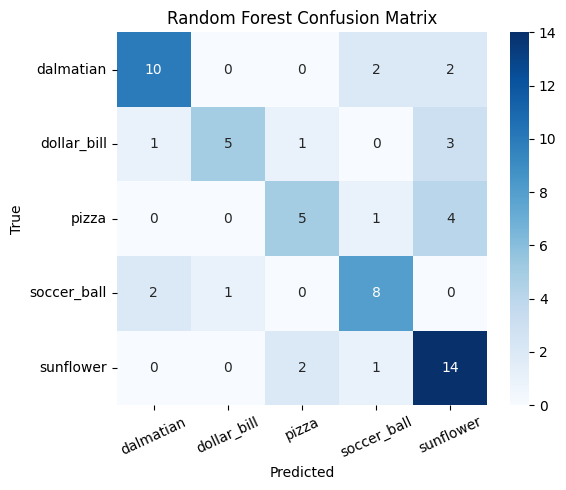

In [25]:
print(classification_report(y_test, rf_pred))
rf_cm = confusion_matrix(y_test, rf_pred, labels=sorted(np.unique(y)))
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Feature importance visualization
Because the images are flattened, each feature corresponds to a pixel location in the 20x20 grayscale image.

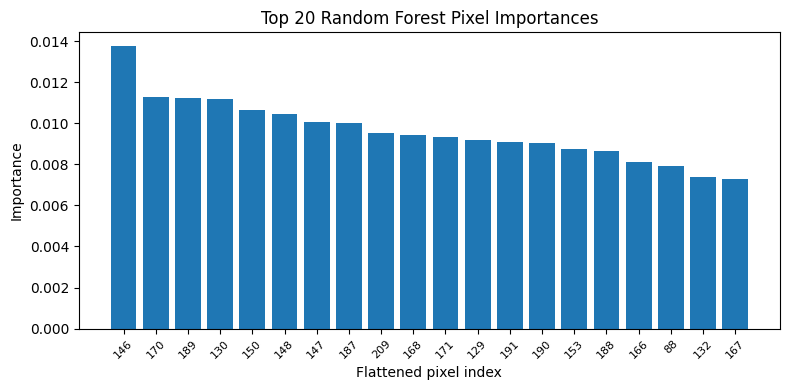

In [26]:
importances = best_rf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
plt.figure(figsize=(8,4))
plt.bar(range(20), importances[top_idx])
plt.title('Top 20 Random Forest Pixel Importances')
plt.xlabel('Flattened pixel index')
plt.ylabel('Importance')
plt.xticks(range(20), [str(i) for i in top_idx], rotation=45, fontsize=8)
plt.tight_layout()
plt.show()


## 5. Predict a new image

In [27]:
def preprocess_single_image(image_path, size=(20,20)):
    img = Image.open(image_path).convert('L').resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr.flatten().reshape(1, -1)

def predict_new_image(model, image_path):
    x_new = preprocess_single_image(image_path)
    return model.predict(x_new)[0]

new_image_path = path_test[0]
predicted_class = predict_new_image(best_rf, new_image_path)
print('New image path:', new_image_path)
print('Predicted class:', predicted_class)
print('Actual class:', y_test[0])


New image path: /content/images_extracted/images/dalmatian/image_0040.jpg
Predicted class: dalmatian
Actual class: dalmatian


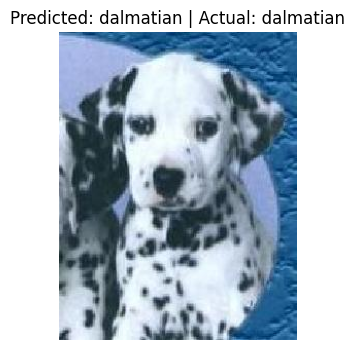

In [28]:
img = Image.open(new_image_path)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f'Predicted: {predicted_class} | Actual: {y_test[0]}')
plt.axis('off')
plt.show()


## 6. Bonus: Compare with SVM

In [29]:
svm_param = {
    'C': [1, 10],
    'gamma': ['scale', 'auto']
}
svm = SVC(kernel='rbf')
svm_grid = GridSearchCV(svm, svm_param, cv=cv, scoring='accuracy', n_jobs=1)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
print('Best SVM parameters:', svm_grid.best_params_)


Best SVM parameters: {'C': 10, 'gamma': 'scale'}


In [30]:
svm_pred = best_svm.predict(X_test)
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, svm_pred)],
    'Precision': [precision_score(y_test, rf_pred, average='weighted', zero_division=0), precision_score(y_test, svm_pred, average='weighted', zero_division=0)],
    'Recall': [recall_score(y_test, rf_pred, average='weighted', zero_division=0), recall_score(y_test, svm_pred, average='weighted', zero_division=0)],
    'F1-score': [f1_score(y_test, rf_pred, average='weighted', zero_division=0), f1_score(y_test, svm_pred, average='weighted', zero_division=0)]
}).round(3)
results


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.677,0.694,0.677,0.673
1,SVM,0.677,0.688,0.677,0.676


## 7. Interpretation and deployment notes
- Random Forest and SVM both achieve moderate performance on this small five-class image dataset.
- SVM slightly improves weighted F1-score, while Random Forest offers native feature importance and easier interpretability.
- For production, package preprocessing and the trained model into a single inference service. Monitor input drift, prediction confidence, class imbalance, and latency over time.